In [1]:
from IPython.display import HTML
HTML('''<style>.jp-Cell-inputWrapper, .input { margin-top: 0.5em; }</style>''')

# Notebook 04 — Logistic Regression (Stacked Dataset)
## ENGG2112 Project MODR

First ML model in the comparison study, trained on the stacked multi-disease dataset (357 rows: flu + COVID + RSV).

### Why logistic regression
1. Outputs P(outbreak) directly — feeds into the SIR simulation
2. Coefficients are interpretable
3. Policy levers compose well
4. Standard ML baseline

### What's different from before
- **357 rows** instead of 141 (2.5× expansion)
- **`StratifiedGroupKFold(groups=fips)`** so the same county's flu + COVID + RSV rows always go in the same fold
- **Disease dummies** as features — model can learn disease-specific demographic effects
- **Same county appears 1-3×** depending on disease availability — group CV prevents leakage

### Evaluation
- Headline: **PR-AUC** (random baseline = positive rate)
- Calibration: Brier + curve
- Bootstrap coefficient CIs

### Output
- `models/lr_model.pkl` — fitted model
- `models/lr_metrics.json` — metrics + bootstrap CIs

## 1. Setup

In [2]:
import json, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import StratifiedGroupKFold, cross_val_predict
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, brier_score_loss,
    confusion_matrix, classification_report, roc_curve, precision_recall_curve
)
from sklearn.calibration import calibration_curve

PROJECT_ROOT = Path.cwd().parent
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
MODELS_DIR = PROJECT_ROOT / 'models'
MODELS_DIR.mkdir(exist_ok=True)

plt.rcParams.update({'figure.figsize': (12, 6), 'axes.titlesize': 13, 'axes.labelsize': 11,
                      'figure.dpi': 100, 'axes.spines.top': False, 'axes.spines.right': False})
sns.set_style('whitegrid')

# Load
master = pd.read_csv(PROCESSED_DIR / 'master_stacked.csv', dtype={'fips': str, 'state_fips': str})
with open(PROCESSED_DIR / 'selected_features.json') as f:
    fc = json.load(f)
DEMO = fc['demographic']
DISEASE_DUMMIES = fc['disease_dummies']
STATE_DUMMIES = fc['state_dummies']
print(f'Stacked dataset: {master.shape}')
print(f'Demographic features ({len(DEMO)}): {DEMO}')
print(f'Disease dummies: {DISEASE_DUMMIES}')
print(f'State dummies: {STATE_DUMMIES}')

Stacked dataset: (357, 39)
Demographic features (5): ['pct_foreign_born', 'avg_household_size', 'pop_density_per_sqmi', 'public_transport_pct', 'pct_elderly']
Disease dummies: ['disease_FLU', 'disease_RSV']
State dummies: ['state_DE', 'state_NY', 'state_PA']


## 2. Build Feature Matrix

In [3]:
disease_X = pd.get_dummies(master['disease'], prefix='disease', drop_first=True).astype(float)
state_X = pd.get_dummies(master['state'], prefix='state', drop_first=True).astype(float)

scaler = StandardScaler()
demo_X = pd.DataFrame(scaler.fit_transform(master[DEMO]), columns=DEMO, index=master.index)

X = pd.concat([demo_X, disease_X[DISEASE_DUMMIES], state_X[STATE_DUMMIES]], axis=1)
y = master['outbreak'].astype(int).values
groups = master['fips'].values

print(f'X shape: {X.shape}')
print(f'Outbreak rate: {y.mean():.1%}')
print(f'Unique counties: {len(set(groups))}')

with open(MODELS_DIR / 'lr_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

X shape: (357, 10)
Outbreak rate: 26.1%
Unique counties: 149


## 3. Train + Evaluate with StratifiedGroupKFold

In [4]:
cv = StratifiedGroupKFold(n_splits=5)

# Out-of-fold predictions for honest metrics
# Use fixed C since LogisticRegressionCV with groups is awkward in current sklearn
# Pick C via simple grid search across folds

from sklearn.model_selection import GridSearchCV

base_lr = LogisticRegression(penalty='l2', solver='lbfgs', class_weight='balanced',
                             max_iter=2000, random_state=42)
grid = GridSearchCV(base_lr, param_grid={'C': [0.01, 0.1, 1.0, 10.0]},
                    cv=cv, scoring='average_precision', n_jobs=-1)
grid.fit(X, y, groups=groups)
best_C = grid.best_params_['C']
print(f'Best C: {best_C}')
print(f'Best CV PR-AUC: {grid.best_score_:.3f}')

# Now compute out-of-fold predictions with the best C
cv_estimator = LogisticRegression(C=best_C, penalty='l2', solver='lbfgs',
                                   class_weight='balanced', max_iter=2000, random_state=42)
oof_proba = cross_val_predict(cv_estimator, X, y, cv=cv, method='predict_proba', groups=groups)[:, 1]
oof_pred = (oof_proba >= 0.5).astype(int)

# Final model fit on all data
model = LogisticRegression(C=best_C, penalty='l2', solver='lbfgs',
                            class_weight='balanced', max_iter=2000, random_state=42)
model.fit(X, y)
print(f'\nFinal model fit on all {len(y)} observations')

Best C: 0.01
Best CV PR-AUC: 0.471

Final model fit on all 357 observations


## 4. Performance Metrics

In [5]:
positive_rate = y.mean()

metrics = {
    'accuracy': accuracy_score(y, oof_pred),
    'precision': precision_score(y, oof_pred, zero_division=0),
    'recall': recall_score(y, oof_pred, zero_division=0),
    'f1': f1_score(y, oof_pred, zero_division=0),
    'roc_auc': roc_auc_score(y, oof_proba),
    'pr_auc': average_precision_score(y, oof_proba),
    'brier': brier_score_loss(y, oof_proba),
}

print('Cross-validated metrics (out-of-fold, group-split CV):\n')
for k, v in metrics.items():
    marker = ' ← HEADLINE' if k == 'pr_auc' else ''
    print(f'  {k:<12s}: {v:.3f}{marker}')

print(f'\nBaselines:')
print(f'  Always-zero accuracy: {1 - positive_rate:.3f}')
print(f'  Random PR-AUC:        {positive_rate:.3f}')

print(f'\n=== Classification report ===')
print(classification_report(y, oof_pred, target_names=['Non-outbreak', 'Outbreak']))

Cross-validated metrics (out-of-fold, group-split CV):

  accuracy    : 0.669
  precision   : 0.368
  recall      : 0.376
  f1          : 0.372
  roc_auc     : 0.610
  pr_auc      : 0.446 ← HEADLINE
  brier       : 0.231

Baselines:
  Always-zero accuracy: 0.739
  Random PR-AUC:        0.261

=== Classification report ===
              precision    recall  f1-score   support

Non-outbreak       0.78      0.77      0.78       264
    Outbreak       0.37      0.38      0.37        93

    accuracy                           0.67       357
   macro avg       0.57      0.57      0.57       357
weighted avg       0.67      0.67      0.67       357



## 5. Confusion Matrix, ROC, PR

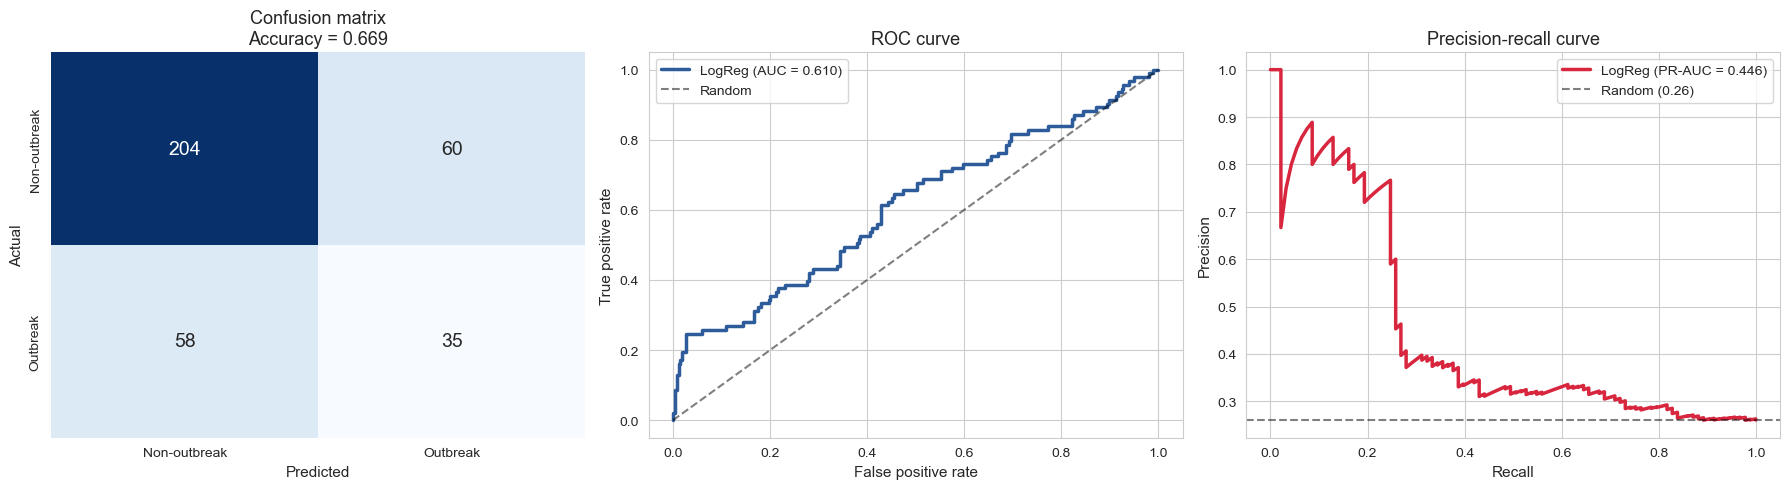

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion
ax = axes[0]
cm = confusion_matrix(y, oof_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Non-outbreak', 'Outbreak'], yticklabels=['Non-outbreak', 'Outbreak'],
            cbar=False, annot_kws={'size': 14})
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title(f'Confusion matrix\nAccuracy = {metrics["accuracy"]:.3f}')

# ROC
ax = axes[1]
fpr, tpr, _ = roc_curve(y, oof_proba)
ax.plot(fpr, tpr, color='#2E5C9A', linewidth=2.5, label=f'LogReg (AUC = {metrics["roc_auc"]:.3f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
ax.set_xlabel('False positive rate'); ax.set_ylabel('True positive rate')
ax.set_title('ROC curve'); ax.legend()

# PR
ax = axes[2]
prec, rec, _ = precision_recall_curve(y, oof_proba)
ax.plot(rec, prec, color='#D7263D', linewidth=2.5, label=f'LogReg (PR-AUC = {metrics["pr_auc"]:.3f})')
ax.axhline(positive_rate, color='black', linestyle='--', alpha=0.5, label=f'Random ({positive_rate:.2f})')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-recall curve'); ax.legend()

plt.tight_layout(); plt.show()

## 6. Calibration

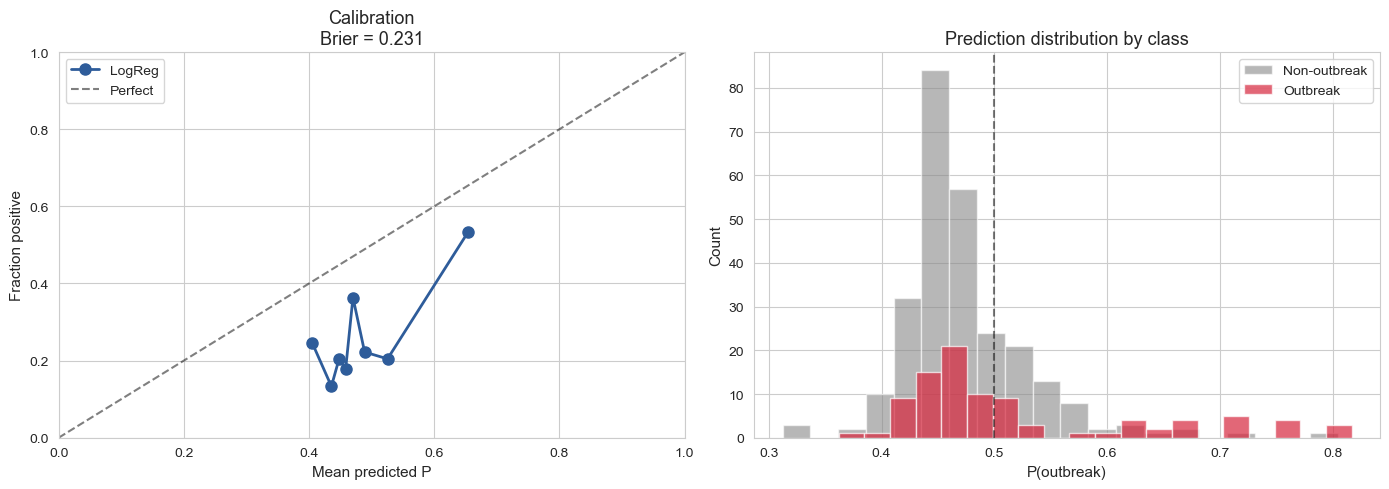

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
prob_true, prob_pred = calibration_curve(y, oof_proba, n_bins=8, strategy='quantile')
ax.plot(prob_pred, prob_true, marker='o', color='#2E5C9A', linewidth=2, markersize=8, label='LogReg')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect')
ax.set_xlabel('Mean predicted P'); ax.set_ylabel('Fraction positive')
ax.set_title(f'Calibration\nBrier = {metrics["brier"]:.3f}')
ax.legend(); ax.set_xlim(0, 1); ax.set_ylim(0, 1)

ax = axes[1]
ax.hist(oof_proba[y == 0], bins=20, alpha=0.6, color='#888888', label='Non-outbreak', edgecolor='white')
ax.hist(oof_proba[y == 1], bins=20, alpha=0.7, color='#D7263D', label='Outbreak', edgecolor='white')
ax.axvline(0.5, color='black', linestyle='--', alpha=0.5)
ax.set_xlabel('P(outbreak)'); ax.set_ylabel('Count')
ax.set_title('Prediction distribution by class')
ax.legend()

plt.tight_layout(); plt.show()

## 7. Bootstrap Coefficient CIs

In [8]:
N_BOOT = 1000
rng = np.random.default_rng(42)
boot_coefs = np.zeros((N_BOOT, X.shape[1]))

for b in range(N_BOOT):
    idx = rng.choice(len(y), size=len(y), replace=True)
    if len(np.unique(y[idx])) < 2:
        boot_coefs[b] = np.nan
        continue
    bm = LogisticRegression(C=best_C, penalty='l2', solver='lbfgs',
                             class_weight='balanced', max_iter=2000, random_state=42)
    bm.fit(X.iloc[idx], y[idx])
    boot_coefs[b] = bm.coef_[0]

boot_df = pd.DataFrame({
    'feature': X.columns,
    'point_estimate': model.coef_[0],
    'mean': np.nanmean(boot_coefs, axis=0),
    'std': np.nanstd(boot_coefs, axis=0),
    'ci_lower': np.nanpercentile(boot_coefs, 2.5, axis=0),
    'ci_upper': np.nanpercentile(boot_coefs, 97.5, axis=0),
})
boot_df['stable'] = (boot_df['ci_lower'] * boot_df['ci_upper'] > 0)

print('Bootstrap analysis (1000 resamples):\n')
print(boot_df.round(3).to_string(index=False))
n_stable = boot_df['stable'].sum()
print(f'\nStable coefficients (CI does not cross zero): {n_stable}/{len(boot_df)}')

Bootstrap analysis (1000 resamples):

             feature  point_estimate   mean   std  ci_lower  ci_upper  stable
    pct_foreign_born           0.139  0.138 0.035     0.068     0.203    True
  avg_household_size           0.189  0.188 0.047     0.091     0.279    True
pop_density_per_sqmi           0.040  0.039 0.039    -0.041     0.107   False
public_transport_pct           0.091  0.090 0.029     0.035     0.146    True
         pct_elderly          -0.023 -0.021 0.051    -0.122     0.076   False
         disease_FLU          -0.003 -0.004 0.041    -0.094     0.074   False
         disease_RSV           0.017  0.018 0.035    -0.048     0.091   False
            state_DE           0.004  0.004 0.014    -0.020     0.034   False
            state_NY          -0.050 -0.052 0.034    -0.117     0.020   False
            state_PA           0.039  0.041 0.035    -0.028     0.107   False

Stable coefficients (CI does not cross zero): 3/10


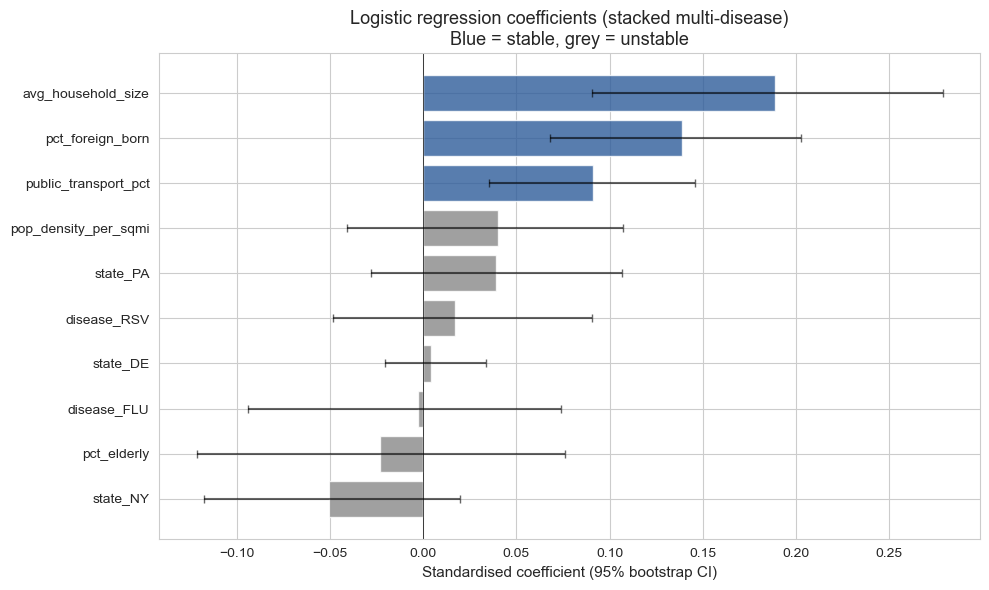

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
sorted_df = boot_df.sort_values('point_estimate')
y_pos = range(len(sorted_df))
colors = ['#2E5C9A' if s else '#888888' for s in sorted_df['stable']]
ax.barh(y_pos, sorted_df['point_estimate'], color=colors, alpha=0.8,
        xerr=[sorted_df['point_estimate'] - sorted_df['ci_lower'],
              sorted_df['ci_upper'] - sorted_df['point_estimate']],
        error_kw={'ecolor': 'black', 'capsize': 3, 'alpha': 0.6}, edgecolor='white')
ax.set_yticks(list(y_pos))
ax.set_yticklabels(sorted_df['feature'])
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel('Standardised coefficient (95% bootstrap CI)')
ax.set_title('Logistic regression coefficients (stacked multi-disease)\nBlue = stable, grey = unstable')
plt.tight_layout(); plt.show()

## 8. Per-Disease Performance

In [10]:
per_pred = pd.DataFrame({
    'fips': master['fips'],
    'disease': master['disease'],
    'state': master['state'],
    'true': y,
    'pred': oof_pred,
    'proba': oof_proba,
})

per_disease = per_pred.groupby('disease').apply(lambda g: pd.Series({
    'n': len(g),
    'positives': g['true'].sum(),
    'pr_auc': average_precision_score(g['true'], g['proba']) if g['true'].sum() > 0 else np.nan,
    'roc_auc': roc_auc_score(g['true'], g['proba']) if g['true'].nunique() == 2 else np.nan,
    'accuracy': accuracy_score(g['true'], g['pred']),
}), include_groups=False).round(3)

print('Performance by disease:\n')
print(per_disease.to_string())

per_state = per_pred.groupby('state').apply(lambda g: pd.Series({
    'n': len(g),
    'positives': g['true'].sum(),
    'pr_auc': average_precision_score(g['true'], g['proba']) if g['true'].sum() > 0 else np.nan,
    'accuracy': accuracy_score(g['true'], g['pred']),
}), include_groups=False).round(3)

print('\nPerformance by state:\n')
print(per_state.to_string())

Performance by disease:

             n  positives  pr_auc  roc_auc  accuracy
disease                                             
COVID    140.0       36.0   0.554    0.658     0.736
FLU      141.0       37.0   0.479    0.650     0.695
RSV       76.0       20.0   0.228    0.402     0.500

Performance by state:

           n  positives  pr_auc  accuracy
state                                    
CT      26.0        8.0   0.309     0.423
DE       6.0        2.0   0.417     0.667
NY     124.0       32.0   0.734     0.887
PA     201.0       51.0   0.218     0.567


## 9. Save Artifacts

In [11]:
artifact = {
    'model': model, 'scaler': scaler,
    'feature_names': list(X.columns),
    'best_C': float(best_C),
    'metrics': metrics,
}
with open(MODELS_DIR / 'lr_model.pkl', 'wb') as f:
    pickle.dump(artifact, f)
print(f'✅ models/lr_model.pkl')

metrics_export = {
    'model': 'LogisticRegression',
    'dataset': 'master_stacked.csv',
    'n_observations': int(len(y)),
    'n_features': int(X.shape[1]),
    'positive_class_rate': float(y.mean()),
    'cv_strategy': 'StratifiedGroupKFold(n_splits=5, groups=fips)',
    'best_C': float(best_C),
    'penalty': 'l2',
    'class_weight': 'balanced',
    'cv_metrics': {k: float(v) for k, v in metrics.items()},
    'baseline_pr_auc': float(positive_rate),
    'coefficients': [
        {'feature': str(r['feature']), 'point_estimate': float(r['point_estimate']),
         'mean': float(r['mean']), 'ci_95_lower': float(r['ci_lower']),
         'ci_95_upper': float(r['ci_upper']), 'stable_sign': bool(r['stable'])}
        for _, r in boot_df.iterrows()
    ],
    'per_disease_performance': per_disease.to_dict(orient='index'),
    'per_state_performance': per_state.to_dict(orient='index'),
}
with open(MODELS_DIR / 'lr_metrics.json', 'w') as f:
    json.dump(metrics_export, f, indent=2)
print(f'✅ models/lr_metrics.json')

✅ models/lr_model.pkl
✅ models/lr_metrics.json


## 10. Summary

In [12]:
print('=== Logistic Regression Summary (Stacked Dataset) ===\n')
print(f'Dataset: master_stacked.csv ({len(y)} rows: flu + COVID + RSV)')
print(f'Features: {X.shape[1]} ({len(DEMO)} demographic + {len(DISEASE_DUMMIES)} disease + {len(STATE_DUMMIES)} state)')
print(f'\nHeadline performance (CV with StratifiedGroupKFold):')
print(f'  PR-AUC:    {metrics["pr_auc"]:.3f}  (random baseline: {positive_rate:.3f})')
print(f'  ROC-AUC:   {metrics["roc_auc"]:.3f}')
print(f'  Accuracy:  {metrics["accuracy"]:.3f}')
print(f'  F1:        {metrics["f1"]:.3f}')
print(f'  Brier:     {metrics["brier"]:.3f}')
print(f'\nCoefficient stability: {n_stable}/{len(boot_df)} stable')
print(f'\n👉 Next: Notebook 05 (Random Forest), 06 (XGBoost), 07 (KNN), 08 (comparison).')

=== Logistic Regression Summary (Stacked Dataset) ===

Dataset: master_stacked.csv (357 rows: flu + COVID + RSV)
Features: 10 (5 demographic + 2 disease + 3 state)

Headline performance (CV with StratifiedGroupKFold):
  PR-AUC:    0.446  (random baseline: 0.261)
  ROC-AUC:   0.610
  Accuracy:  0.669
  F1:        0.372
  Brier:     0.231

Coefficient stability: 3/10 stable

👉 Next: Notebook 05 (Random Forest), 06 (XGBoost), 07 (KNN), 08 (comparison).
